# <u>LIMPIEZA DEL DATASET:</u>

In [1]:
import numpy as np
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [2]:
df = pd.read_csv('../data/cars.csv')

## <u>TIPADO DE DATOS:</u>

In [3]:
df.dtypes

manufacturer            object
model                   object
year                     int64
mileage                float64
engine                  object
transmission            object
drivetrain              object
fuel_type               object
mpg                     object
exterior_color          object
interior_color          object
accidents_or_damage    float64
one_owner              float64
personal_use_only      float64
seller_name             object
seller_rating          float64
driver_rating          float64
driver_reviews_num     float64
price_drop             float64
price                  float64
dtype: object

In [4]:
df.dtypes.to_dict()

{'manufacturer': dtype('O'),
 'model': dtype('O'),
 'year': dtype('int64'),
 'mileage': dtype('float64'),
 'engine': dtype('O'),
 'transmission': dtype('O'),
 'drivetrain': dtype('O'),
 'fuel_type': dtype('O'),
 'mpg': dtype('O'),
 'exterior_color': dtype('O'),
 'interior_color': dtype('O'),
 'accidents_or_damage': dtype('float64'),
 'one_owner': dtype('float64'),
 'personal_use_only': dtype('float64'),
 'seller_name': dtype('O'),
 'seller_rating': dtype('float64'),
 'driver_rating': dtype('float64'),
 'driver_reviews_num': dtype('float64'),
 'price_drop': dtype('float64'),
 'price': dtype('float64')}

### <u>'manufacturer to drivetrain'</u>

- La columna `manufacturer` la ponemos como tipo **string** porque representa el fabricante del modelo en formato texto.
- La columna `model` corresponde al modelo del vehículo. Igual que manufacturer, la ponemos como **string**, es una variable categórica.
- La columna `year` la ponemos como tipo **Int64**, ya que indica el año de fabricación del coche. Es un número entero y no requiere decimales.
- La columna `mileage` la ponemos como tipo **float64**, ya que los datos del dataset incluyen decimales en los valores de los km.
- La columna `engine` la ponemos como tipo **string** aunque después la vamos a dividir en varias columnas.
- La columna `transmission` la ponemos como tipo **string**, ya que nos indica si el coche es manual o automático.
- La columna `drivetrain` la ponemos como tipo **string**, porque almacena el sistema de tracción del coche.

In [5]:
df = df.astype({
    'manufacturer': 'string',
    'model': 'string',
    'year': 'Int64',
    'mileage': 'float64',
    'engine': 'string',
    'transmission': 'string',
    'drivetrain': 'string'
})

### <u>'fuel_type to personal_use_only'</u>

- La columna `fuel_type` la ponemos como tipo **string** porque representa el tipo de combustible de cada vehículo
- La columna `mpg` la ponemos como **string**, ya que representa un rango entre el minimo y el maximo, aunque luego la vamos a dividir en dos.
- La columna `exterior_color` la ponemos como tipo **string**, ya que indica el color del exterior. Luego la vamos a eliminar.
- La columna `interior_color` la ponemos como tipo **string**, ya que indica el color del interior. Luego la vamos a eliminar.
- La columna `accidents_or_damage` la ponemos como tipo **Int64** ya que es una variable binaria(1 o 0).
- La columna `one_owner` la ponemos como tipo **Int64**, ya que es una variable binaria(1 o 0).
- La columna `personal_use_only` la ponemos como tipo **Int64**, ya que es una variable binaria(1 o 0).

In [6]:
df = df.astype({
    'fuel_type': 'string',
    'mpg': 'string',
    'exterior_color': 'string',
    'interior_color': 'string',
    'accidents_or_damage': 'Int64',
    'one_owner': 'Int64',
    'personal_use_only': 'Int64'
})

### <u>'seller_name to price'</u>

- La columna `seller_name` la ponemos como tipo **string**, ya que contiene el nombre del vendedor en formato texto.
- La columna `seller_rating` la ponemos como tipo **float64**, porque representa una valoración numérica con decimales.
- La columna `driver_rating` la ponemos como tipo **float64**, ya que también es una valoración numérica con decimales.
- La columna `driver_reviews_num` la ponemos como tipo **Int64**, porque almacena el número de reseñas y es un valor entero, pero queremos permitir valores nulos (`NaN`).
- La columna `price_drop` la ponemos como tipo **float64**, dado que representa una variación de precio (rebaja) que incluye decimales.
- La columna `price` la ponemos como tipo **Int64**, porque el precio del vehículo se maneja como valor entero, y así mantenemos compatibilidad con valores nulos si los hubiera.


In [7]:
df = df.astype({
    'seller_name': 'string',
    'seller_rating': 'float64',
    'driver_rating': 'float64',
    'driver_reviews_num': 'Int64',
    'price_drop': 'float64',
    'price': 'Int64'
})

## <u>VALORES ERRÓNEOS:</u>

In [8]:
pd.isnull(df).sum()

manufacturer                0
model                       0
year                        0
mileage                   506
engine                  15050
transmission             9904
drivetrain              21562
fuel_type               22927
mpg                    142071
exterior_color           8859
interior_color          56975
accidents_or_damage     24212
one_owner               31483
personal_use_only       24852
seller_name              8593
seller_rating          213973
driver_rating           31632
driver_reviews_num          0
price_drop             351979
price                       0
dtype: int64

In [9]:
pd.isnull(df[[x for x in df.columns[pd.isnull(df).any()].tolist()]]).sum()

mileage                   506
engine                  15050
transmission             9904
drivetrain              21562
fuel_type               22927
mpg                    142071
exterior_color           8859
interior_color          56975
accidents_or_damage     24212
one_owner               31483
personal_use_only       24852
seller_name              8593
seller_rating          213973
driver_rating           31632
price_drop             351979
dtype: int64

In [10]:
df[df.isna().any(axis=1)][[x for x in df.columns[pd.isnull(df).any()]]]

,mileage,engine,transmission,drivetrain,fuel_type,mpg,exterior_color,interior_color,accidents_or_damage,one_owner,personal_use_only,seller_name,seller_rating,driver_rating,price_drop
0,92945.0,"1.5L I-4 i-VTEC variable valve control, engine...",Automatic,Front-wheel Drive,Gasoline,39-38,Black,Parchment,0,0,0,Iconic Coach,NaN,4.4,300.0
1,47645.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Gray,Ebony,1,1,1,Kars Today,NaN,4.4,NaN
3,117598.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Polished Metal Metallic,<NA>,0,1,1,Apple Tree Acura,NaN,4.4,675.0
4,114865.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,<NA>,Ebony,1,0,1,Herb Connolly Chevrolet,3.7,4.4,300.0
6,57212.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Silver,Ebony,0,1,1,Ohio Car Mart,NaN,4.4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762082,6302.0,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,All-wheel Drive,Gasoline,25-33,Birch Light Metallic,Charcoal,0,1,0,Scott Volvo Cars Allentown,NaN,4.2,NaN
762083,13972.0,2.0L I4 16V GDI DOHC,8-Speed Automatic,All-wheel Drive,Gasoline,21-32,White,<NA>,0,1,0,Simmons-Rockwell Hyundai,NaN,4.9,NaN
762087,72900.0,250.0HP 2.5L 5 Cylinder Engine Gasoline Fuel,A/T,Front-wheel Drive,Gasoline,<NA>,Red,Beige,<NA>,<NA>,<NA>,<NA>,NaN,4.5,NaN
762088,92000.0,2.5L I5 20V MPFI DOHC Turbo,6-Speed Automatic,Front-wheel Drive,Gasoline,21-30,Ice White,Soft Beige,0,0,1,Dapper Car Sales,NaN,4.8,300.0


### <u>'mileage'</u>
##### Hemos imputado los valores faltantes de mileage usando una estrategia escalonada, rellenando primero por manufacturer + model + year y después por medianas de fabricante y globales. Así hemos obtenido un kilometraje coherente con la edad y el tipo de coche, evitando perder datos valiosos.

In [11]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)

    df['mileage'] = (
        df.groupby(['manufacturer', 'model', 'year'])['mileage']
          .transform(lambda x: x.fillna(x.median()))
    )

##### Estamos rellenando los valores nulos con la mediana teniendo en cuenta las columnas: 'manufacturer','model','year'.

In [12]:
df['mileage'] = df['mileage'].fillna(df['mileage'].median())

##### Tras rellenar los ausentes de 'mileage' con la mediana de 'manufacturer','model','year', nos siguen quedando 20 valores nulos. A estos últimos le hemos rellenado los valores teniendo en cuenta la mediana de 'mileage'.

In [13]:
df['mileage'].describe()

count    7.620910e+05
mean     5.577397e+04
std      4.356073e+04
min      0.000000e+00
25%      2.327400e+04
50%      4.559000e+04
75%      7.836300e+04
max      1.119067e+06
Name: mileage, dtype: float64

### <u>'engine'</u>
##### Hemos limpiado la columna engine dividiéndola en tres variables numéricas y categóricas: engine_liters, engine_cylinders y engine_type. Después hemos imputado los valores faltantes de litros y cilindros usando medianas por grupos coherentes (manufacturer + model + year + cylinders), quedando listas para ML

In [14]:
df['engine_clean'] = df['engine'].str.lower()

##### Extraemos la cilindrada (litros)

In [15]:
def extract_liters(x):
    if pd.isna(x):
        return None
    match = re.search(r'(\d\.\d|\d)\s*l', x)
    if match:
        return float(match.group(1))
    return None

df['engine_liters'] = df['engine_clean'].apply(extract_liters)

##### Extraemos el número de cilindridos

In [16]:
def extract_cylinders(x):
    if pd.isna(x):
        return None
    match = re.search(r'(v|i|l)(\d)', x)
    if match:
        return int(match.group(2))
    return None

df['engine_cylinders'] = df['engine_clean'].apply(extract_cylinders)

In [17]:
df[df['engine_cylinders'] % 1 != 0]

,manufacturer,model,year,mileage,engine,transmission,drivetrain,fuel_type,mpg,exterior_color,...,personal_use_only,seller_name,seller_rating,driver_rating,driver_reviews_num,price_drop,price,engine_clean,engine_liters,engine_cylinders
0,Acura,ILX Hybrid 1.5L,2013,92945.0,"1.5L I-4 i-VTEC variable valve control, engine...",Automatic,Front-wheel Drive,Gasoline,39-38,Black,...,0,Iconic Coach,NaN,4.4,12,300.0,13988,"1.5l i-4 i-vtec variable valve control, engine...",1.5,NaN
7,Acura,ILX Hybrid 1.5L,2014,214000.0,111.0HP 1.5L 4 Cylinder Engine Gasoline/Mild E...,A/T,Front-wheel Drive,Hybrid,<NA>,White,...,<NA>,<NA>,NaN,3.7,7,NaN,8500,111.0hp 1.5l 4 cylinder engine gasoline/mild e...,1.5,NaN
14,Acura,NSX Base,2017,15904.0,Twin Turbo Gas/Electric V-6 3.5 L/213,Automatic,All-wheel Drive,Hybrid,21-22,130R White,...,1,Piazza Acura / Honda of Reading,4.7,4.8,17,2111.0,139876,twin turbo gas/electric v-6 3.5 l/213,3.5,NaN
17,Acura,NSX T,1995,320000.0,<NA>,5-Speed M/T,Rear-wheel Drive,<NA>,<NA>,Red,...,<NA>,<NA>,NaN,5.0,3,NaN,75500,<NA>,NaN,NaN
19,Acura,NSX Base,2022,1447.0,"3.5L V-6 port/direct injection, DOHC, VTC vari...",Automatic,All-wheel Drive,Gasoline,21-22,Berlina Black,...,1,European Exotic Center,NaN,NaN,0,5000.0,254995,"3.5l v-6 port/direct injection, dohc, vtc vari...",3.5,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762046,Volvo,S60 T5,2013,153673.0,"2.5L I-5 DOHC, variable valve control, interco...",Automatic,Front-wheel Drive,Gasoline,21-30,GRAY,...,1,Web Autos,NaN,4.7,62,NaN,8495,"2.5l i-5 dohc, variable valve control, interco...",2.5,NaN
762064,Volvo,S60 T5 Premier,2013,50755.0,"2.5L I-5 DOHC, variable valve control, interco...",Automatic,All-wheel Drive,Gasoline,20-29,GRAY,...,<NA>,1st International Auto Group,2.6,4.7,62,NaN,15555,"2.5l i-5 dohc, variable valve control, interco...",2.5,NaN
762075,Volvo,S60 Momentum,2020,52559.0,4 Cylinder Engine,Automatic,Front-wheel Drive,Gasoline,<NA>,Osmium Grey,...,1,Stillman Volvo Cars,NaN,4.9,24,200.0,26800,4 cylinder engine,NaN,NaN
762077,Volvo,S60 T5 Momentum,2020,13778.0,I-4 cyl,Automatic with Geartronic,Front-wheel Drive,Gasoline,<NA>,Crystal White Pearl,...,1,Ontario Volvo Cars,NaN,4.9,24,NaN,29975,i-4 cyl,NaN,NaN


In [18]:
df = df[df['engine_cylinders'] % 1 == 0]

In [19]:
df['engine_cylinders'] = df['engine_cylinders'].astype('Int64')

##### Extraemos el tipo de motor

In [20]:
def extract_engine_type(x):
    if pd.isna(x):
        return "unknown"
    if "turbo" in x or "t" in x:
        return "turbo"
    if "super" in x:
        return "supercharged"
    if "electric" in x:
        return "electric"
    if "hybrid" in x:
        return "hybrid"
    return "natural"

df['engine_type'] = df['engine_clean'].apply(extract_engine_type)

##### Si engine es electric: 
##### litros=0; 
##### cilindros=0
##### Si creamos estas 3 columnas para diferenciar realmente entre la cilindrada, el número de cilindros y el tipo de motor podemos eliminar posteriormente 'engine_clean':

In [21]:
df.drop(columns=['engine_clean'], inplace=True)

In [22]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)

    df['engine_liters'] = (
        df.groupby(['manufacturer', 'model'])['engine_liters']
          .transform(lambda x: x.fillna(x.median()))
    )

##### A los missing values de la nueva columna 'engine_liters', le hemos imputado la mediana teniendo en cuenta las columnas 'manufacturer' y 'model'.

In [23]:
df['engine_liters'] = df.groupby(['manufacturer'])['engine_liters'] \
                         .transform(lambda x: x.fillna(x.median()))

##### Como nos siguen quedan valores nulos después de la imputación anterior, le hemos imputado de nuevo la mediana pero ahora teniendo solo en cuenta 'manufacturer'.

In [24]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)

    df['engine_cylinders'] = (
        df.groupby(['manufacturer', 'model'])['engine_cylinders']
          .transform(lambda x: x.fillna(x.median()))
    )

##### A los missing values de la nueva columna 'engine_cylinders', le hemos imputado la mediana teniendo en cuenta las columnas 'manufacturer' y 'model'. 

In [25]:
df['engine_cylinders'] = df.groupby(['manufacturer'])['engine_cylinders'] \
                            .transform(lambda x: x.fillna(x.median()))

##### Como nos siguen quedan valores nulos después de la imputación anterior, le hemos imputado de nuevo la mediana pero ahora teniendo solo en cuenta 'manufacturer'.

In [26]:
df.drop(columns=['engine'], inplace=True)

### <u>'transmission'</u>
##### Hemos clasificado y unificado todos los valores de transmission en automatic, manual y unknown, detectando variantes como A/T, CVT, Dual-Clutch, 8-speed, etc., y hemos eliminado los registros clasificados como “other” tras limpiar la columna correctamente.

In [27]:
df['transmission_clean'] = df['transmission'].astype(str).str.lower()

def simplify_transmission(x):
    if pd.isna(x) or x.strip() == "":
        return "unknown"
    
    if any(word in x for word in [
        "automatic",          
        "auto ", " auto",     
        "a/t", "at",
        "cvt", 
        "continuously variable", 
        "variable",
        "dct", 
        "dual", 
        "tiptronic", 
        "dsg",
        "shift",
        "8-speed", "8 speed", "8spd",
        "7-speed", "7 speed", "7spd",
        "9-speed", "9 speed", "9spd",
        "10-speed", "10 speed", "10spd"
    ]):
        return "automatic"
    
    if any(word in x for word in [
        "manual",
        "m/t", "mt",
        "man ",
        "5-speed", "5 speed",
        "6-speed", "6 speed",
        "5spd", "6spd"
    ]):
        return "manual"
    
    return "other"

df['transmission_simple'] = df['transmission_clean'].apply(simplify_transmission)
df = df.drop(columns=['transmission_clean'])


In [28]:
df = df[df['transmission_simple'] != 'other']

In [29]:
df.drop(columns=['transmission'], inplace=True)

### <u>'drivetrain'</u>
##### Hemos normalizado todos los valores de drivetrain en las 4 categorías principales (Front-wheel, Rear-wheel, All-wheel, Four-wheel Drive), y eliminado los registros “unknown” y “other” para quedarnos solo con configuraciones de tracción válidas.

In [30]:
df['drivetrain'].value_counts()

drivetrain
Front-wheel Drive                                              210827
All-wheel Drive                                                178203
Four-wheel Drive                                               139090
Rear-wheel Drive                                                79175
FWD                                                              6263
AWD                                                              2921
4WD                                                              1900
RWD                                                              1605
Unknown                                                            63
Front-Wheel Drive                                                  59
Four-Wheel Drive with Locking and Limited-Slip Differential        42
Front-Wheel Drive with Limited-Slip Differential                   38
All-Wheel Drive with Locking and Limited-Slip Differential         33
All-Wheel Drive with Locking Differential                          20
Rear-Whee

In [31]:
df['drivetrain_clean'] = df['drivetrain'].astype(str).str.lower()

def simplify_drivetrain(x):
    if pd.isna(x) or x.strip() == "" or x == "nan":
        return "unknown" 

    if any(word in x for word in [
        "front-wheel", "front wheel", "fwd"
    ]):
        return "Front-wheel Drive"

    if any(word in x for word in [
        "rear-wheel", "rear wheel", "rwd"
    ]):
        return "Rear-wheel Drive"
    
    if any(word in x for word in [
        "all-wheel", "all wheel", "awd"
    ]):
        return "All-wheel Drive"
    
    if any(word in x for word in [
        "four-wheel", "four wheel",
        "4wd", "4x4", "4 x 4"
    ]):
        return "Four-wheel Drive"
    
    return "other"

df['drivetrain_simple'] = df['drivetrain_clean'].apply(simplify_drivetrain)
df = df.drop(columns=['drivetrain_clean'])

In [32]:
df = df[df['drivetrain_simple'] != 'unknown']
df = df[df['drivetrain_simple'] != 'other']

In [33]:
df['drivetrain_simple'].value_counts()

drivetrain_simple
Front-wheel Drive    217189
All-wheel Drive      181191
Four-wheel Drive     141068
Rear-wheel Drive      80815
Name: count, dtype: int64

In [34]:
df.drop(columns=['drivetrain'], inplace=True)

### <u>'fuel_type'</u>
##### Con fuel_type hemos estandarizado todos los valores en 4 categorías limpias (Gasoline, Diesel, Hybrid, Electric),y¡ y hemos eliminado los registros “unknown” y “other” para quedarnos solo con combustibles válidos y consistentes para el modelo.

In [35]:
df['fuel_clean'] = df['fuel_type'].astype(str).str.lower()

def simplify_fuel(x):
    if pd.isna(x) or x.strip() == "" or x == "nan":
        return "unknown"
    
    if any(word in x for word in [
        "gas", "gasoline", 
        "unleaded", "regular", "petrol"
    ]):
        return "Gasoline"
    
    if any(word in x for word in [
        "diesel", "tdi", "dci", "crdi"
    ]):
        return "Diesel"
    
    if any(word in x for word in [
        "hybrid", "phev", "plug-in"
    ]):
        return "Hybrid"
    
    if any(word in x for word in [
        "electric", "ev", "battery"
    ]):
        return "Electric"
    
    return "other"

df['fuel_simple'] = df['fuel_clean'].apply(simplify_fuel)
df = df.drop(columns=['fuel_clean'])

In [36]:
df['fuel_simple'].value_counts()

fuel_simple
Gasoline    543818
Hybrid       27106
other        24872
Diesel       24313
Electric       154
Name: count, dtype: int64

In [37]:
df = df[(df['fuel_simple'] != 'unknown') &
        (df['fuel_simple'] != 'other')]

### <u>'mpg'</u>
##### Hemos convertido los rangos de mpg en dos columnas numéricas (mpg_min y mpg_max), corrigiendo incluso los rangos invertidos. Después hemos imputado sus valores faltantes usando medianas por grupos coherentes (manufacturer + model + engine_cylinders).

In [38]:
def parse_ordered_mpg(x):
    if pd.isna(x):
        return (np.nan, np.nan)
    
    x = str(x).strip().replace("–", "-")
    
    if "-" not in x:
        try:
            v = float(x)
            return (v, v)
        except:
            return (np.nan, np.nan)
    
    nums = re.findall(r'\d+', x)
    
    if len(nums) == 2:
        a, b = float(nums[0]), float(nums[1])
        return (min(a, b), max(a, b)) 
    
    return (np.nan, np.nan)

df[['mpg_min', 'mpg_max']] = df['mpg'].apply(lambda x: pd.Series(parse_ordered_mpg(x)))

In [39]:
df[['mpg', 'mpg_min', 'mpg_max']].head(20)

,mpg,mpg_min,mpg_max
1,39-38,38.0,39.0
2,39-38,38.0,39.0
3,39-38,38.0,39.0
4,39-38,38.0,39.0
5,39-38,38.0,39.0
6,39-38,38.0,39.0
8,39-38,38.0,39.0
10,21-22,21.0,22.0
11,<NA>,NaN,NaN
12,21-22,21.0,22.0


In [40]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)

    for col in ['mpg_min', 'mpg_max']:
        df[col] = (
            df.groupby(['manufacturer', 'model', 'engine_cylinders'])[col]
              .transform(lambda x: x.fillna(x.median()))
        )

##### A los missing values de las nuevas columnas 'mpg_min y mpg_max', le hemos imputado la mediana teniendo en cuenta las columnas 'manufacturer', 'model' y 'engine_cylinders'.

In [41]:
for col in ['mpg_min', 'mpg_max']:
    df[col] = df.groupby('engine_cylinders')[col] \
                .transform(lambda x: x.fillna(x.median()))

##### Como nos siguen quedan valores nulos después de la imputación anterior, le hemos imputado de nuevo la mediana pero ahora teniendo solo en cuenta 'engine_cylinders'

In [42]:
df['mpg_min'] = df['mpg_min'].fillna(df['mpg_min'].median())
df['mpg_max'] = df['mpg_max'].fillna(df['mpg_max'].median())

##### Tras rellenar los ausentes de 'mpg_min' y 'mpg_max' con la mediana de manufacturer','model','engine_cylinders', nos siguen quedando valores nulos, pero muy pocos. A estos últimos le hemos rellenado los valores teniendo en cuenta la mediana en general.

In [43]:
df = df.drop(columns=['mpg'])

### <u>'exterior_color' y 'interior_color'</u>

##### Hemos decidido eliminar las columnas de los colores ya que no tienen un aporte significativo a la hora de predcir el precio, el cual es nuestro objetivo.

In [44]:
df = df.drop(columns=['exterior_color', 'interior_color'])

### <u>Columnas binarias:</u>

##### Para los valores nulos de las columnas: 'accidents_or_damage, one_owner y personal_use_only', al ser columnas binarias, hemos decidido imputar los valores nulos siguiendo la distribución ya existente de la variable. Calculando las distribuciones e imputando después.

#### 'accidents_or_damage':

In [45]:
dist = df['accidents_or_damage'].value_counts(normalize=True)
dist

accidents_or_damage
0    0.768955
1    0.231045
Name: proportion, dtype: Float64

In [46]:
df['accidents_or_damage'] = df['accidents_or_damage'].fillna(
    np.random.choice(dist.index, p=dist.values)
)

#### 'one_owner':

In [47]:
dist1 = df['one_owner'].value_counts(normalize=True)
dist1

one_owner
1    0.565949
0    0.434051
Name: proportion, dtype: Float64

In [48]:
df['one_owner'] = df['one_owner'].fillna(
    np.random.choice(dist.index, p=dist.values)
)

#### 'personal_use_only':

In [49]:
dist2 = df['personal_use_only'].value_counts(normalize=True)
dist2

personal_use_only
1    0.65512
0    0.34488
Name: proportion, dtype: Float64

In [50]:
df['personal_use_only'] = df['personal_use_only'].fillna(
    np.random.choice(dist.index, p=dist.values)
)

### <u>'seller_name'</u>

In [51]:
df['seller_name'].unique()

<StringArray>
[                       'Kars Today',      'Weiss Toyota of South County',
                  'Apple Tree Acura',           'Herb Connolly Chevrolet',
                        'Kalidy Kia',                     'Ohio Car Mart',
        'Napleton's Palatine Subaru',         'Stingray Chevrolet Bartow',
               'D & C Motor Company',                       'Mark Motors',
 ...
                'Performance Toyota',           'Berglund Luxury Roanoke',
 'Serra Volvo Cars of Traverse City',         'Lehman Volvo Cars of York',
                'Junge Cedar Rapids',            'Cherry Hill Volvo Cars',
  'Premier Volvo Cars Overland Park',             'McGoldrick Automotive',
             'Motorcars Acura Volvo',                     'Audi Gwinnett']
Length: 14200, dtype: string

In [52]:
df['seller_name'].isna().sum()

np.int64(2264)

In [53]:
n_miss = df['seller_name'].isna().sum()
pct_miss = df['seller_name'].isna().mean() * 100
print(n_miss, pct_miss)

2264 0.380254320270209


##### seller_name presenta un 1% de valores faltantes, probablemente asociados a vendedores que no informan de un nombre comercial o anuncios de particulares, no se eliminan estas filas por tratarse de un porcentaje reducido.

In [54]:
df['seller_name'] = df['seller_name'].fillna('Unknown_seller')

### <u>'seller_rating'</u>

In [55]:
df['seller_rating'].unique()

array([nan, 4.3, 3.7, 2.2, 4.6, 3.3, 3.5, 4.5, 4.8, 1.8, 4.7, 4.2, 3.6,
       3.2, 2.8, 4.9, 2.6, 4.4, 2.4, 5. , 3.9, 2.1, 4.1, 1.5, 3.4, 4. ,
       3.1, 2.5, 2.9, 3.8, 3. , 2. , 2.3, 1.7, 1.3, 2.7, 1.9, 1.6, 1. ,
       1.2, 1.4, 1.1])

In [56]:
df['seller_rating'].isna().sum()

np.int64(146461)

In [57]:

bins = [1, 2, 3, 4, 5.0001]  
labels = ['1-2', '2-3', '3-4', '4-5']

df['seller_rating_cat'] = pd.cut(
    df['seller_rating'],
    bins=bins,
    labels=labels,
    right=False
)


df['seller_rating_cat'] = df['seller_rating_cat'].astype(object)
df.loc[df['seller_rating'].isna(), 'seller_rating_cat'] = 'sin valoración'


df = df.drop(columns=['seller_rating'])

##### La variable seller_rating toma valores entre 1 y 5 y presenta un 28% de valores faltantes, se ha discretizado en rangos (1–2), (2–3), (3–4) y (4–5), creando la variable categórica seller_rating_cat. Las observaciones sin valoración se han agrupado en una categoría adicional sin valoración. Tras esta transformación, la variable numérica original seller_rating se ha eliminado del conjunto de datos, trabajando únicamente con su versión categórica.

### <u>'driver_rating'<u>

In [58]:
df['driver_rating'].unique()

array([4.4, 3.8, 4.7, 4.8, 4.1, 4.9, 5. , nan, 4. , 4.6, 4.5, 4.3, 4.2,
       3. , 3.9, 3.7, 3.5, 1. , 3.3, 3.4, 3.2, 2.5, 2.8, 3.6, 3.1, 2.9,
       2. , 1.3, 2.7, 2.6, 1.9, 2.1, 1.7, 2.2])

In [59]:
df['driver_rating'].isna().sum()

np.int64(23461)

In [60]:
bins = [1, 2, 3, 4, 5.0001]
labels = ['1-2', '2-3', '3-4', '4-5']

df['driver_rating_cat'] = pd.cut(
    df['driver_rating'],
    bins=bins,
    labels=labels,
    right=False 
)


df['driver_rating_cat'] = df['driver_rating_cat'].astype(object)
df.loc[df['driver_rating'].isna(), 'driver_rating_cat'] = 'sin valoración'


df = df.drop(columns=['driver_rating'])

##### La variable driver_rating toma valores entre 1 y 5 y presenta un 4% de valores faltantes, se ha discretizado en rangos (1–2), (2–3), (3–4) y (4–5), creando la variable categórica driver_rating_cat. Las observaciones sin valoración se han agrupado en una categoría adicional sin valoración. Tras esta transformación, la variable numérica original seller_rating se ha eliminado del conjunto de datos, trabajando únicamente con su versión categórica.

### <u>'drivers_reviews_num'</u>

In [61]:
df['driver_reviews_num'].unique()

<IntegerArray>
[ 12,   2,   3,  17,   1,   0,   5,  14,   4,   8,
 ...
 771, 149, 383, 334, 170, 314, 241, 391, 289, 189]
Length: 361, dtype: Int64

In [62]:
df['driver_reviews_num'].isna().sum()

np.int64(0)

##### Ningún missing.

### <u>'price'</u>

##### Esta columna será nuestro tag/etiqueta.

In [63]:
df['price'].unique()

<IntegerArray>
[ 17995,  17000,  14958,  14498,  18000,  15999,  16950, 156890, 109990,
 139888,
 ...
   4197,  36567,  41311,  32864,   8532,  42004,  36328,  41861,   4563,
  14818]
Length: 58488, dtype: Int64

In [64]:
df['price'].isna().sum()

np.int64(0)

##### Ningún missing.

### <u>'Price_drop'</u>

In [65]:
df['price_drop'].unique()

array([  nan,  500.,  675., ..., 6382., 4758., 5244.], shape=(5962,))

In [66]:
df['price_drop'].isna().sum()

np.int64(259136)

In [67]:
df = df.drop(columns=['price_drop'])

##### La variable price_drop refleja la rebaja del precio respecto al precio inicial del anuncio y presenta un 46 % de valores faltantes. Además, los NA no pueden interpretarse de forma consistente (aparecen en vehículos de múltiples años y segmentos) y la variable está asociada a decisiones posteriores a la fijación del precio. Por estos motivos, se ha decidido excluir price_drop del conjunto de variables utilizadas en el modelado.

## <u>OUTLIERS:</u>

### <u>'mileage'</u>

In [68]:
to_delete_1 = df[(df['mileage'] > 400000) & (df['year'] > 2015)]
to_delete_2 = df[(df['mileage'] > 400000) & (df['year'] < 1990)]

to_delete = pd.concat([to_delete_1, to_delete_2])

df = df.drop(to_delete.index)

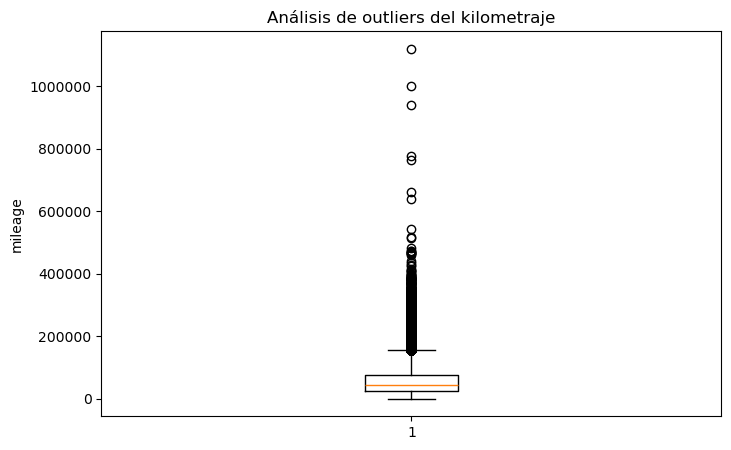

In [69]:
plt.figure(figsize=(8,5))
plt.boxplot(df['mileage'], vert=True)
plt.title('Análisis de outliers del kilometraje')
plt.ylabel('mileage')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

##### Tras revisar los outliers de mileage, hay que saber interpretarlos. Vemos algunos registros que no son nada fiables. Por ejemplo, un Toyota Camry LE del 2020 con 769.938 km.También vemos un Porsche 359 A de 1959 con un 1.000.0000 de km aprox. Hemos decidido eliminar los registros cuyo 'year' sea superior al 2017 y tengan más de 400.000 km. Es muy complicado hacerle tantos km en tan pocos años, ni siquiera un taxista o un camionero llega a esos números. También vamos a eliminar los coches cuyo 'year' sea inferior a 1990 y tengan más de 400.000 km ya que los coches de los 60-70-80 no tenían motores capaces de ser tan duraderos. En la década de los 90, se comienzan a fabricar coches con motores potentes, de los cuales algunos han llegado posteriormente al millón de km con un mantenimiento adecuado.

### <u>'engine_liters'<u>

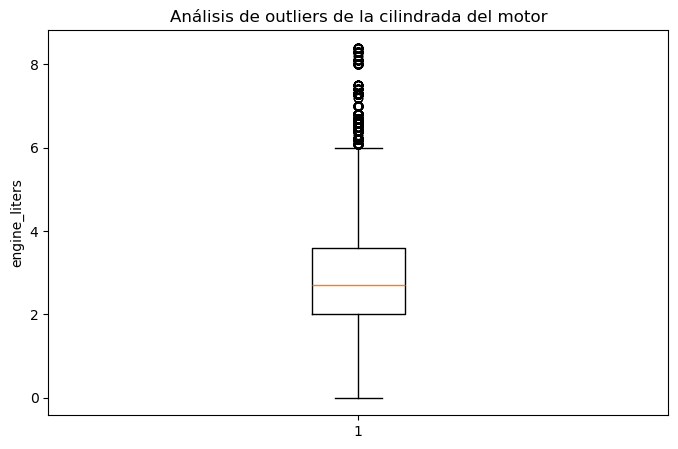

In [70]:
plt.figure(figsize=(8,5))
plt.boxplot(df['engine_liters'], vert=True)
plt.title('Análisis de outliers de la cilindrada del motor')
plt.ylabel('engine_liters')
plt.show()

In [71]:
df = df[(df['engine_liters'] >= 1.0) & (df['engine_liters'] <= 7.5)]

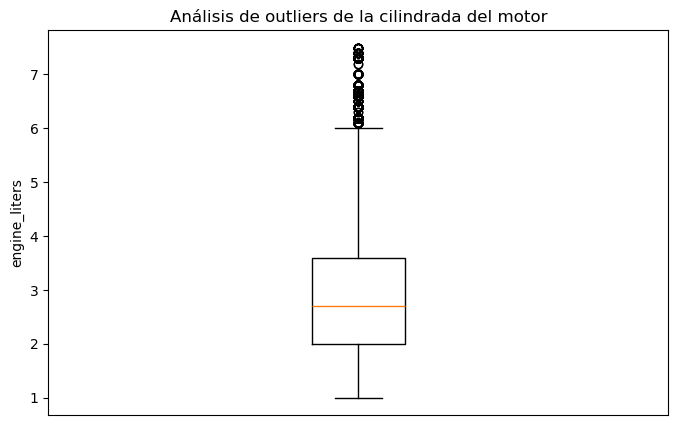

In [72]:
plt.figure(figsize=(8,5))
plt.boxplot(df['engine_liters'], vert=True)
plt.title('Análisis de outliers de la cilindrada del motor')
plt.ylabel('engine_liters')
plt.xticks([])
plt.show()

##### Para la detección de los outliers de 'engine_liters' hemos seguido la lógica del sector automovilístico y hemos eliminado los registros que se encontraban fuera del umbral 1L – 7.5L. En EEUU no existen motores de combustión menores de 1 litro salvo casos muy excepcionales al igual que los que superan los 7.5L, por eso nos quedamos con los registros que se encuentren de este umbral.

### <u>'drivers_reviews_num'<u>

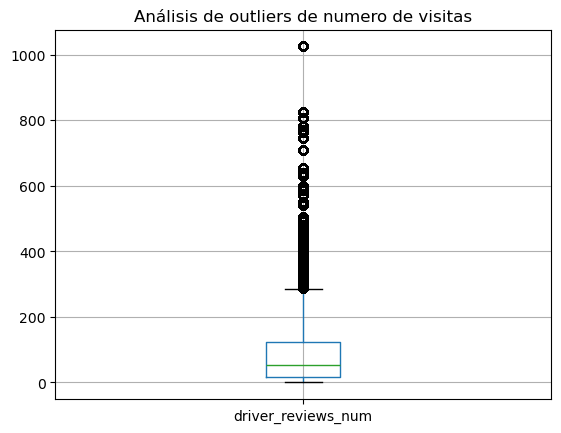

In [73]:
df[['driver_reviews_num']].boxplot()
plt.title('Análisis de outliers de numero de visitas')
plt.show()

In [74]:
umbral_alto_reviews = df['driver_reviews_num'].quantile(0.995)
df = df[df['driver_reviews_num'] <= umbral_alto_reviews]

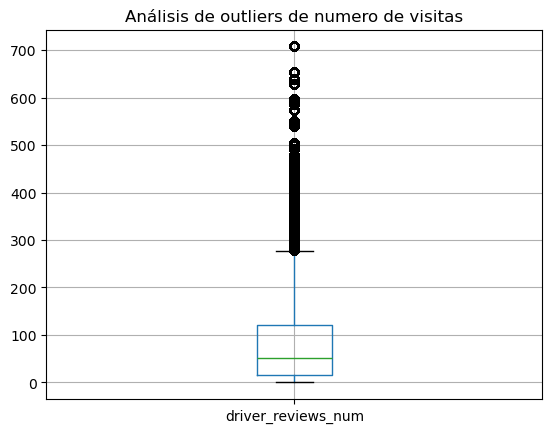

In [75]:
df[['driver_reviews_num']].boxplot()
plt.title('Análisis de outliers de numero de visitas')
plt.show()

##### En cuanto a los outliers de drivers_review_num, entendiendo que pudiera haber algún valor erróneo extremadamente lejano del global de datos se ha decidido eliminar un porcentaje diminuto de la cola superior, aunque pudiera haber algún anuncio de coche extramadamente popular, no se entiende se llegue a casos extremos.

### <u>'mpg_min y mpg_max'</u>

##### Hemos borrado todas las filas en las que no existe valor en mpg_min y mpg_max

In [76]:
df = df[df['mpg_min'] > 0]

### <u>'price'</u>

##### Nuestro tag/etiqueta.

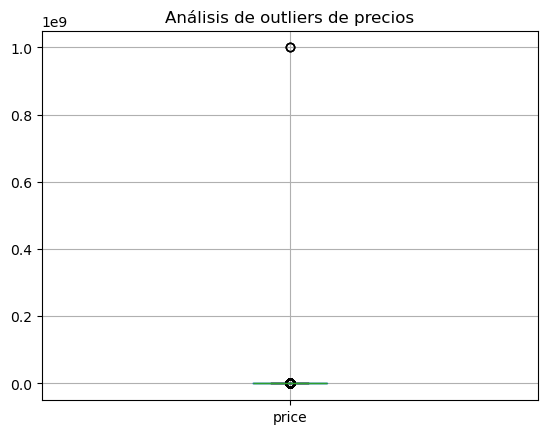

In [77]:
df[['price']].boxplot()
plt.title('Análisis de outliers de precios')
plt.show()

In [78]:
print(df['price'].max())
print(df['price'].mean())
print(df['price'].min())

1000000000
36889.51669540406
1


In [79]:
df[df['price'] == df['price'].max()]

,manufacturer,model,year,mileage,fuel_type,accidents_or_damage,one_owner,personal_use_only,seller_name,driver_reviews_num,...,engine_liters,engine_cylinders,engine_type,transmission_simple,drivetrain_simple,fuel_simple,mpg_min,mpg_max,seller_rating_cat,driver_rating_cat
108142,Chevrolet,Cobalt LT,2009,85185.0,Gasoline,0,1,1,"Rothrock Nissan, Chrysler, Dodge, Jeep, RAM",90,...,2.2,4,natural,automatic,Front-wheel Drive,Gasoline,24.0,32.0,4-5,4-5
188113,Dodge,Durango Citadel,2018,113207.0,Gasoline,0,1,1,"Rothrock Nissan, Chrysler, Dodge, Jeep, RAM",146,...,3.6,6,natural,automatic,All-wheel Drive,Gasoline,18.0,25.0,4-5,4-5
188260,Dodge,Durango Citadel,2018,113207.0,Gasoline,0,1,1,"Rothrock Nissan, Chrysler, Dodge, Jeep, RAM",146,...,3.6,6,natural,automatic,All-wheel Drive,Gasoline,18.0,25.0,4-5,4-5


In [80]:
df = df[df['price'] != df['price'].max()]

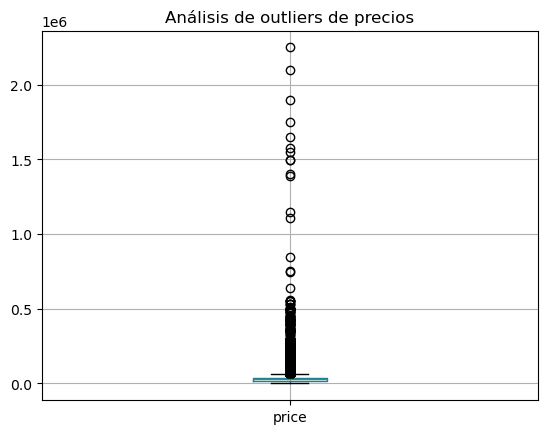

In [81]:
df[['price']].boxplot()
plt.title('Análisis de outliers de precios')
plt.show()

In [82]:
print(df['price'].max())
print(df['price'].mean())
print(df['price'].min())

2250000
31638.179600603577
1


In [83]:
df[df['price'] == df['price'].max()]

,manufacturer,model,year,mileage,fuel_type,accidents_or_damage,one_owner,personal_use_only,seller_name,driver_reviews_num,...,engine_liters,engine_cylinders,engine_type,transmission_simple,drivetrain_simple,fuel_simple,mpg_min,mpg_max,seller_rating_cat,driver_rating_cat
613085,Porsche,Carrera GT,2005,780.0,Gasoline,0,0,0,Hubbard Auto Center of Scottsdale,5,...,5.7,1,natural,manual,Rear-wheel Drive,Gasoline,10.0,16.0,sin valoración,4-5


In [84]:
df = df[df['price'] != df['price'].max()]

In [85]:
df[df['price'] == df['price'].max()]

,manufacturer,model,year,mileage,fuel_type,accidents_or_damage,one_owner,personal_use_only,seller_name,driver_reviews_num,...,engine_liters,engine_cylinders,engine_type,transmission_simple,drivetrain_simple,fuel_simple,mpg_min,mpg_max,seller_rating_cat,driver_rating_cat
609009,Porsche,918 Spyder Base (PDK),2015,2622.0,Hybrid,0,0,1,Graham Rahal Performance,5,...,4.6,8,hybrid,automatic,All-wheel Drive,Hybrid,20.0,24.0,sin valoración,3-4


In [86]:
df = df[df['price'] != df['price'].max()]

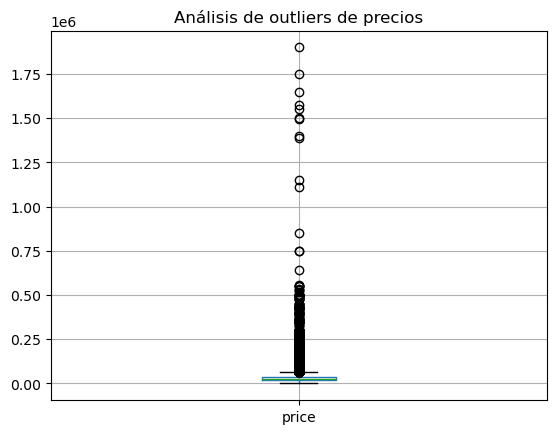

In [87]:
df[['price']].boxplot()
plt.title('Análisis de outliers de precios')
plt.show()

In [88]:
df.nlargest(20, 'price')

,manufacturer,model,year,mileage,fuel_type,accidents_or_damage,one_owner,personal_use_only,seller_name,driver_reviews_num,...,engine_liters,engine_cylinders,engine_type,transmission_simple,drivetrain_simple,fuel_simple,mpg_min,mpg_max,seller_rating_cat,driver_rating_cat
613080,Porsche,Carrera GT,2004,2361.0,Gasoline,0,0,1,Kearns Motor Car Co.,2,...,5.7,1,natural,manual,Rear-wheel Drive,Gasoline,10.0,16.0,4-5,4-5
49078,BMW,750 iL,1996,121043.0,Gasoline,0,0,1,Celebrity Cars Las Vegas,2,...,5.4,1,natural,automatic,Front-wheel Drive,Gasoline,15.0,20.0,4-5,4-5
613084,Porsche,Carrera GT,2005,9610.0,Gasoline,0,0,0,Ilusso,5,...,5.7,1,natural,manual,Rear-wheel Drive,Gasoline,10.0,16.0,sin valoración,4-5
213659,Ford,GT EDITION VIN 002,2018,9.0,Gasoline,0,1,1,HGreg.com Lux,0,...,3.5,6,natural,automatic,Rear-wheel Drive,Gasoline,18.0,25.0,4-5,sin valoración
613079,Porsche,Carrera GT Base (M6),2004,4376.0,Gasoline,0,0,1,Porsche North Houston,2,...,5.7,1,natural,manual,Rear-wheel Drive,Gasoline,10.0,16.0,4-5,4-5
613081,Porsche,Carrera GT,2005,12996.0,Gasoline,0,0,1,Porsche North Olmsted,5,...,5.7,1,natural,manual,Rear-wheel Drive,Gasoline,10.0,16.0,4-5,4-5
613083,Porsche,Carrera GT,2005,5052.0,Gasoline,0,1,1,ZWECK,5,...,5.7,1,natural,manual,Rear-wheel Drive,Gasoline,10.0,16.0,sin valoración,4-5
613082,Porsche,Carrera GT Base (M6),2005,10982.0,Gasoline,0,0,1,Miller Motorcars,5,...,5.7,1,natural,manual,Rear-wheel Drive,Gasoline,10.0,16.0,sin valoración,4-5
613086,Porsche,Carrera GT Base (M6),2005,11750.0,Gasoline,0,0,1,Merit Partners,5,...,5.7,1,natural,manual,Rear-wheel Drive,Gasoline,10.0,16.0,4-5,4-5
540908,Mercedes-Benz,SLR McLaren,2009,650.0,Gasoline,0,0,1,Car Geeks,2,...,5.4,8,supercharged,automatic,Rear-wheel Drive,Gasoline,12.0,16.0,2-3,4-5


In [89]:
umbral_alto = df['price'].quantile(0.999)
print(umbral_alto)

df = df[df['price'] <= umbral_alto]

204995.0


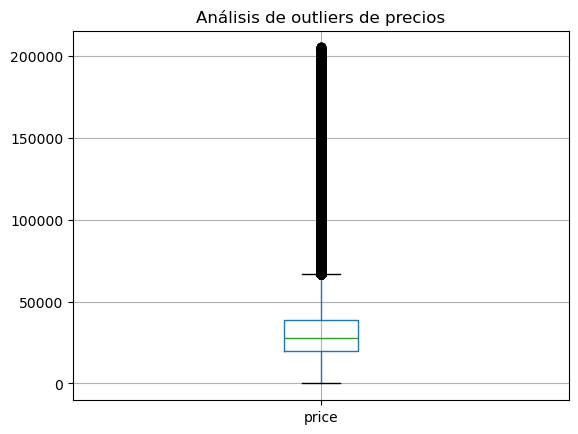

In [90]:
df[['price']].boxplot()
plt.title('Análisis de outliers de precios')
plt.show()

In [91]:
print(df['price'].max())
print(df['price'].mean())
print(df['price'].min())

204995
31373.387482499224
1


In [92]:
df[df['price'] == df['price'].min()]

,manufacturer,model,year,mileage,fuel_type,accidents_or_damage,one_owner,personal_use_only,seller_name,driver_reviews_num,...,engine_liters,engine_cylinders,engine_type,transmission_simple,drivetrain_simple,fuel_simple,mpg_min,mpg_max,seller_rating_cat,driver_rating_cat
5658,Acura,TLX V6 A-Spec,2018,49603.0,Gasoline,1,0,1,Luxury Auto Mall,83,...,3.5,6,natural,automatic,Front-wheel Drive,Gasoline,20.0,30.0,1-2,4-5
13850,Audi,A4 2.0T Premium,2014,98881.0,Gasoline,0,1,0,Luxury Auto Mall,59,...,2.0,4,turbo,automatic,Front-wheel Drive,Gasoline,24.0,32.0,1-2,4-5
735177,Volkswagen,Jetta,2007,133964.0,Gasoline,1,0,1,Fred Anderson Kia,72,...,2.5,5,natural,manual,Front-wheel Drive,Gasoline,22.0,30.0,4-5,4-5


In [93]:
df.nsmallest(20, 'price')

,manufacturer,model,year,mileage,fuel_type,accidents_or_damage,one_owner,personal_use_only,seller_name,driver_reviews_num,...,engine_liters,engine_cylinders,engine_type,transmission_simple,drivetrain_simple,fuel_simple,mpg_min,mpg_max,seller_rating_cat,driver_rating_cat
5658,Acura,TLX V6 A-Spec,2018,49603.0,Gasoline,1,0,1,Luxury Auto Mall,83,...,3.5,6,natural,automatic,Front-wheel Drive,Gasoline,20.0,30.0,1-2,4-5
13850,Audi,A4 2.0T Premium,2014,98881.0,Gasoline,0,1,0,Luxury Auto Mall,59,...,2.0,4,turbo,automatic,Front-wheel Drive,Gasoline,24.0,32.0,1-2,4-5
735177,Volkswagen,Jetta,2007,133964.0,Gasoline,1,0,1,Fred Anderson Kia,72,...,2.5,5,natural,manual,Front-wheel Drive,Gasoline,22.0,30.0,4-5,4-5
66049,Buick,Enclave Premium,2017,115869.0,Gasoline,1,0,1,Lions Pre-Owned,137,...,3.6,6,turbo,automatic,Front-wheel Drive,Gasoline,15.0,22.0,sin valoración,4-5
162360,Chrysler,Pacifica Touring L,2020,55240.0,Gasoline,0,1,0,Lions Pre-Owned,64,...,3.6,6,turbo,automatic,Front-wheel Drive,Gasoline,19.0,28.0,sin valoración,4-5
165200,Dodge,Grand Caravan GT,2019,72860.0,Gasoline,1,1,0,Lions Pre-Owned,70,...,3.6,6,turbo,automatic,Front-wheel Drive,Gasoline,17.0,25.0,sin valoración,4-5
165324,Dodge,Grand Caravan GT,2019,72860.0,Gasoline,1,1,0,Lions Pre-Owned,70,...,3.6,6,turbo,automatic,Front-wheel Drive,Gasoline,17.0,25.0,sin valoración,4-5
566508,Nissan,Maxima SE,2001,157000.0,Gasoline,0,0,1,Patriot Chrysler Dodge Jeep Ram of McAlester,22,...,3.0,6,natural,automatic,Front-wheel Drive,Gasoline,19.0,26.0,3-4,4-5
165031,Dodge,Caravan SE,1997,201611.0,Gasoline,0,0,0,East Coast Auto Source,2,...,3.0,6,natural,automatic,Front-wheel Drive,Gasoline,18.0,25.0,1-2,4-5
760485,Volvo,V70 T5,1998,193695.0,Gasoline,1,0,1,East Coast Auto Source,25,...,2.4,5,turbo,automatic,Four-wheel Drive,Gasoline,20.0,28.0,1-2,4-5


In [94]:
umbral_bajo = df['price'].quantile(0.001) 
print(umbral_bajo)

df = df[df['price'] >= umbral_bajo]

3290.0


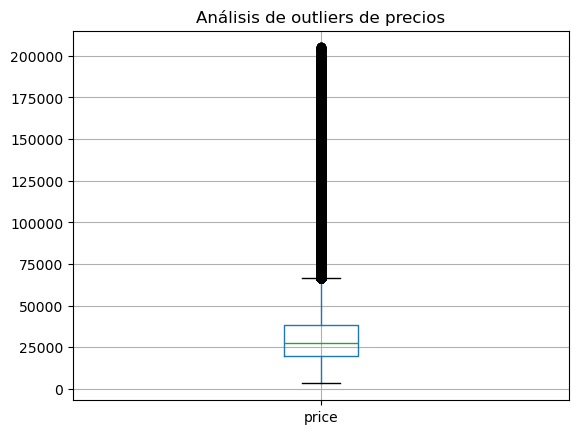

In [95]:
df[['price']].boxplot()
plt.title('Análisis de outliers de precios')
plt.show()

In [96]:
df.nsmallest(20, 'price')

,manufacturer,model,year,mileage,fuel_type,accidents_or_damage,one_owner,personal_use_only,seller_name,driver_reviews_num,...,engine_liters,engine_cylinders,engine_type,transmission_simple,drivetrain_simple,fuel_simple,mpg_min,mpg_max,seller_rating_cat,driver_rating_cat
99986,Chevrolet,Uplander LS Fleet,2006,198629.0,Gasoline,0,1,0,Starfire Auto Inc.,19,...,3.5,6,natural,automatic,Front-wheel Drive,Gasoline,18.0,25.0,3-4,4-5
166874,Dodge,Grand Caravan SE,2005,174542.0,Gasoline,1,0,0,Starfire Auto Inc.,38,...,3.3,6,natural,automatic,Front-wheel Drive,Gasoline,19.0,26.0,3-4,4-5
180377,Dodge,Dakota Sport,2001,156985.0,Gasoline,1,0,1,Starfire Auto Inc.,52,...,4.7,8,natural,automatic,Rear-wheel Drive,Gasoline,20.0,25.0,3-4,4-5
193742,Ford,Focus SE,2002,115724.0,Gasoline,1,0,1,Starfire Auto Inc.,56,...,2.0,4,natural,automatic,Front-wheel Drive,Gasoline,26.0,32.0,3-4,4-5
698875,Toyota,Sienna XLE,2000,189432.0,Gasoline,0,0,1,Starfire Auto Inc.,42,...,3.0,6,natural,automatic,Front-wheel Drive,Gasoline,18.0,24.0,3-4,4-5
728462,Volkswagen,New Beetle GLS,2001,172110.0,Gasoline,0,0,1,Starfire Auto Inc.,25,...,2.0,4,natural,automatic,Front-wheel Drive,Gasoline,22.0,29.0,3-4,4-5
491336,Lincoln,Navigator Luxury,2003,252764.0,Gasoline,0,0,1,Dan Deery Motors,19,...,5.4,8,natural,automatic,Four-wheel Drive,Gasoline,11.0,16.0,4-5,4-5
24819,Audi,A8 L 4.2 quattro,2004,152936.0,Gasoline,0,0,0,East Coast Auto Source,19,...,4.2,8,natural,automatic,All-wheel Drive,Gasoline,17.0,24.0,1-2,4-5
168132,Dodge,Grand Caravan SXT,2006,188744.0,Gasoline,0,0,1,Corwin Public Wholesale,42,...,3.8,6,natural,automatic,Front-wheel Drive,Gasoline,18.0,25.0,4-5,4-5
359363,INFINITI,QX4 Base,2003,178961.0,Gasoline,0,1,0,Unknown_seller,17,...,3.5,6,natural,automatic,Rear-wheel Drive,Gasoline,18.0,25.0,sin valoración,4-5


##### La variable price presenta algunos valores extremadamente bajos y altos que no son representativos del mercado típico de coches de segunda mano y pueden distorsionar el análisis y los modelos.Para reducir su impacto, eliminamos solo los casos más extremos usando percentiles:

##### - Umbral inferior: percentil 0.1% de price.
##### - Umbral superior: percentil 99.9% de price.

##### Nos quedamos únicamente con las observaciones cuyo precio está entre ambos valores.

In [97]:
df

,manufacturer,model,year,mileage,fuel_type,accidents_or_damage,one_owner,personal_use_only,seller_name,driver_reviews_num,...,engine_liters,engine_cylinders,engine_type,transmission_simple,drivetrain_simple,fuel_simple,mpg_min,mpg_max,seller_rating_cat,driver_rating_cat
1,Acura,ILX Hybrid 1.5L,2013,47645.0,Hybrid,1,1,1,Kars Today,12,...,1.5,4,hybrid,automatic,Front-wheel Drive,Hybrid,38.0,39.0,sin valoración,4-5
2,Acura,ILX Hybrid 1.5L,2013,53422.0,Hybrid,0,1,1,Weiss Toyota of South County,12,...,1.5,4,hybrid,automatic,Front-wheel Drive,Hybrid,38.0,39.0,4-5,4-5
3,Acura,ILX Hybrid 1.5L,2013,117598.0,Hybrid,0,1,1,Apple Tree Acura,12,...,1.5,4,hybrid,automatic,Front-wheel Drive,Hybrid,38.0,39.0,sin valoración,4-5
4,Acura,ILX Hybrid 1.5L,2013,114865.0,Hybrid,1,0,1,Herb Connolly Chevrolet,12,...,1.5,4,hybrid,automatic,Front-wheel Drive,Hybrid,38.0,39.0,3-4,4-5
5,Acura,ILX Hybrid 1.5L,2013,62042.0,Hybrid,0,0,1,Kalidy Kia,12,...,1.5,4,hybrid,automatic,Front-wheel Drive,Hybrid,38.0,39.0,2-3,4-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762085,Volvo,S60 T5,2020,26781.0,Gasoline,1,1,1,Jenkins Volvo of Ocala,24,...,2.0,4,turbo,automatic,Front-wheel Drive,Gasoline,23.0,34.0,4-5,4-5
762086,Volvo,S60 B5 Momentum,2022,22877.0,Gasoline,0,1,0,Volvo Cars Danbury,2,...,2.0,4,turbo,automatic,All-wheel Drive,Gasoline,25.0,33.0,4-5,4-5
762088,Volvo,S60 T5,2014,92000.0,Gasoline,0,0,1,Dapper Car Sales,36,...,2.5,5,turbo,automatic,Front-wheel Drive,Gasoline,21.0,30.0,sin valoración,4-5
762089,Volvo,S60 T5 Platinum,2013,132000.0,Gasoline,1,0,0,Legend Auto Sales Inc.,62,...,2.5,5,turbo,automatic,All-wheel Drive,Gasoline,20.0,29.0,4-5,4-5


## <u>GRÁFICOS DE DISTRIBUCIONES:</u>

### <u>Distribución de los fabricantes (top 10 fabricantes más comunes)</u>:

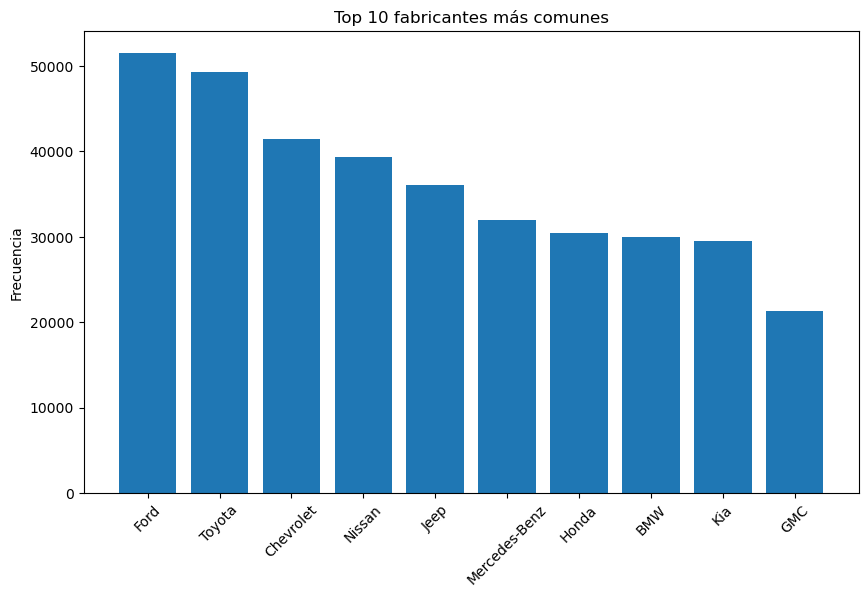

In [98]:
top_manufacturers = df['manufacturer'].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.bar(top_manufacturers.index, top_manufacturers.values)
plt.xticks(rotation=45)
plt.title("Top 10 fabricantes más comunes")
plt.ylabel("Frecuencia")
plt.show()

### <u>Distribución del kilometraje</u>:

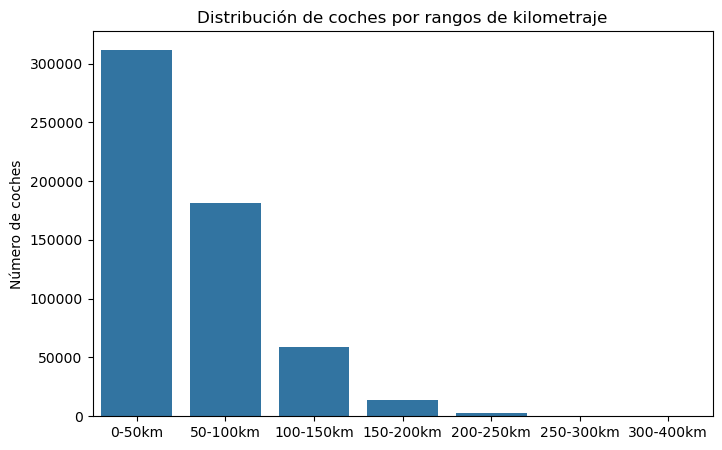

In [99]:
bins = [0, 50000, 100000, 150000, 200000, 250000, 300000, 400000]
labels = ['0-50km','50-100km','100-150km','150-200km','200-250km','250-300km','300-400km']

df['mileage_bin'] = pd.cut(df['mileage'], bins=bins, labels=labels)

plt.figure(figsize=(8,5))
sns.countplot(x='mileage_bin', data=df, order=labels)
plt.title("Distribución de coches por rangos de kilometraje")
plt.xlabel("")
plt.ylabel("Número de coches")
plt.show()

df.drop(columns=['mileage_bin'], inplace=True)

### <u>Distribución de la cilidrada del motor</u>:

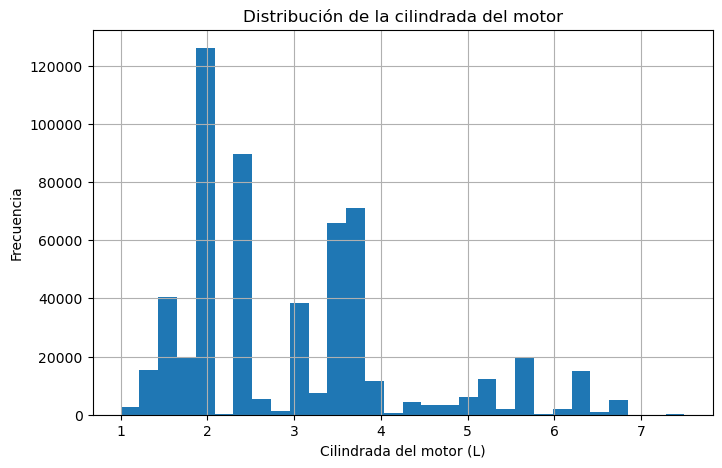

In [100]:
plt.figure(figsize=(8, 5))
df["engine_liters"].dropna().hist(bins=30)
plt.xlabel("Cilindrada del motor (L)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la cilindrada del motor")
plt.show()

### <u>Distribución del número de cilindros</u>:

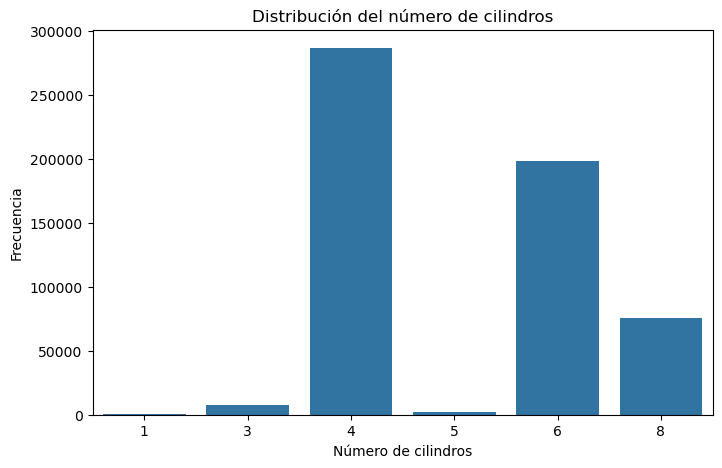

In [101]:
plt.figure(figsize=(8,5))
sns.countplot(x='engine_cylinders', data=df)
plt.title("Distribución del número de cilindros")
plt.xlabel("Número de cilindros")
plt.ylabel("Frecuencia")
plt.show()

### <u>Distribución del tipo de motor</u>:

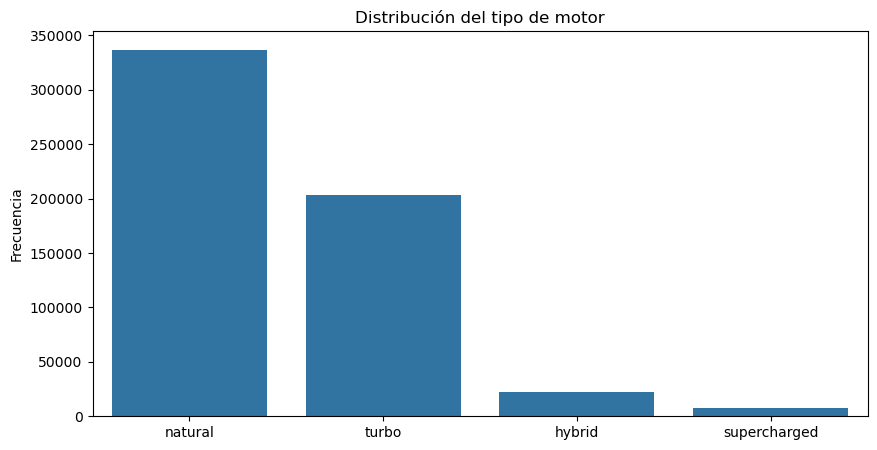

In [102]:
plt.figure(figsize=(10,5))
sns.countplot(x='engine_type', data=df, order=df['engine_type'].value_counts().index)
plt.title("Distribución del tipo de motor")
plt.xlabel("")
plt.ylabel("Frecuencia")
plt.show()

### <u>Distribución de la transmisión</u>:

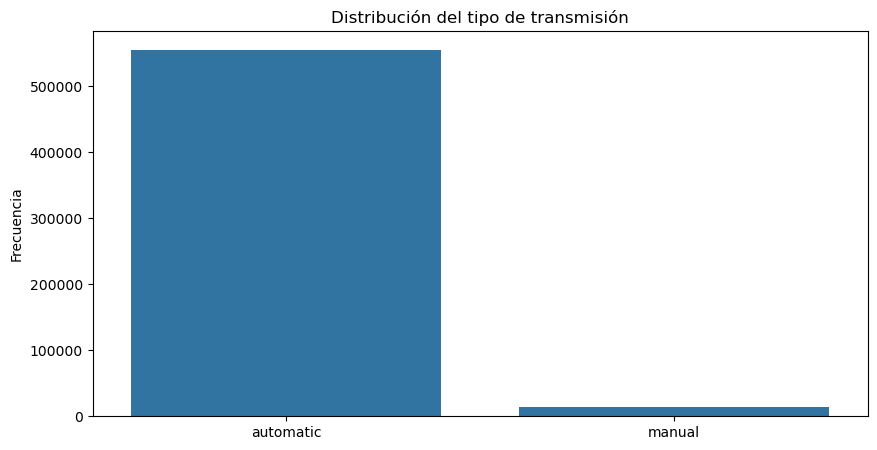

In [103]:
plt.figure(figsize=(10,5))
sns.countplot(x='transmission_simple', data=df, order=df['transmission_simple'].value_counts().index)
plt.title("Distribución del tipo de transmisión")
plt.xlabel("")
plt.ylabel("Frecuencia")
plt.show()

### <u>Distribución del sistema de tracción</u>:

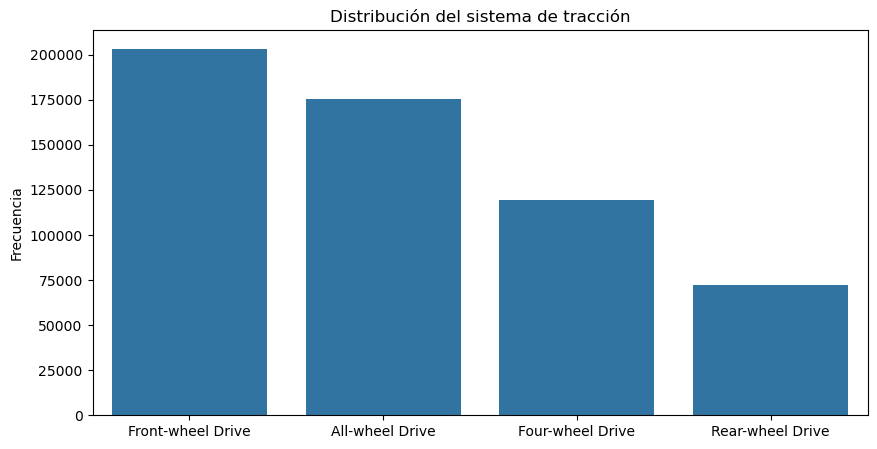

In [104]:
plt.figure(figsize=(10,5))
sns.countplot(x='drivetrain_simple', data=df, order=df['drivetrain_simple'].value_counts().index)
plt.title("Distribución del sistema de tracción")
plt.xlabel("")
plt.ylabel("Frecuencia")
plt.show()

### <u>Distribución del tipo de combustible</u>:

##### fuel_type contiene un montón de clases muy raras, mezclas, formatos inconsistentes y variantes casi duplicadas, por tanto agrupamos las clases que no tienen casi valores en 'otros'

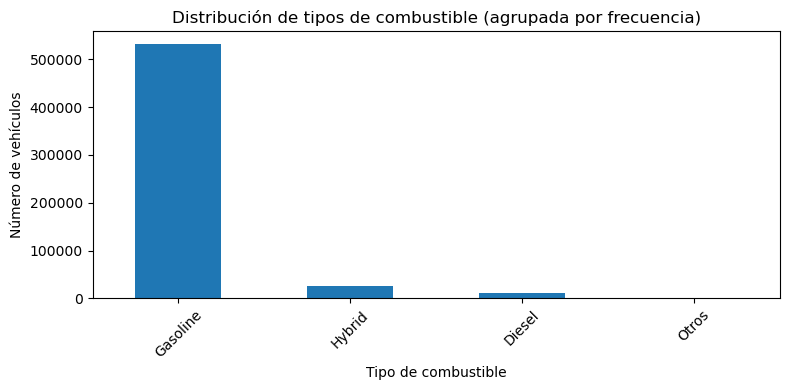

In [105]:
counts = df['fuel_type'].value_counts()
top = counts[counts > 5000] 
other = counts[counts <= 5000].sum()

top["Otros"] = other

top.plot(kind='bar', figsize=(8,4))
plt.title("Distribución de tipos de combustible (agrupada por frecuencia)")
plt.xlabel("Tipo de combustible")
plt.ylabel("Número de vehículos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### <u>Distribución de millas por galón</u>

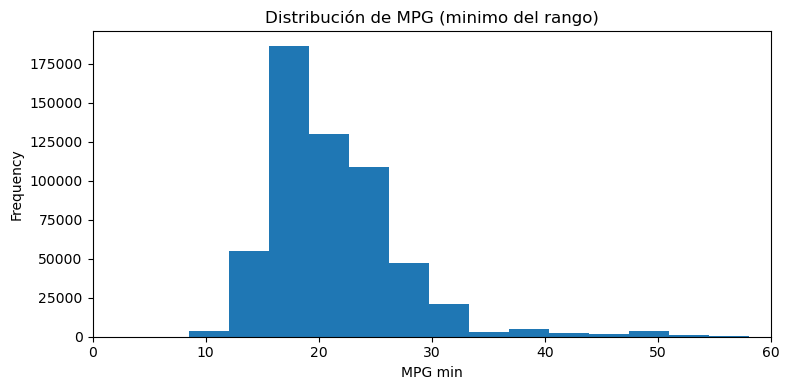

In [106]:
df['mpg_min'].plot(kind='hist', bins=30, figsize=(8,4))
plt.title("Distribución de MPG (minimo del rango)")
plt.xlabel("MPG min")
plt.xlim(0, 60)
plt.tight_layout()
plt.show()


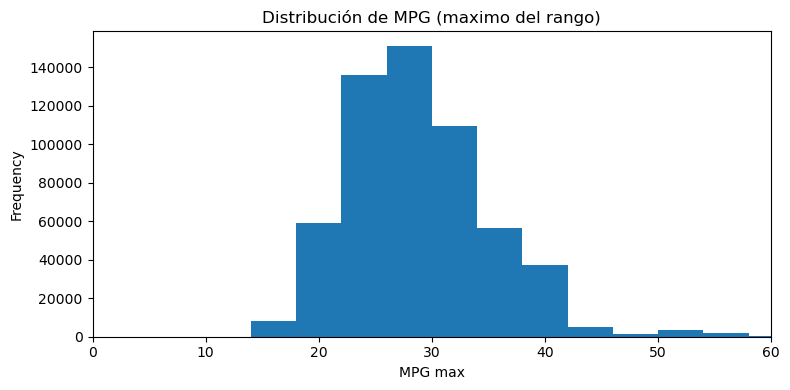

In [107]:
df['mpg_max'].plot(kind='hist', bins=30, figsize=(8,4))
plt.title("Distribución de MPG (maximo del rango)")
plt.xlabel("MPG max")
plt.xlim(0, 60)
plt.tight_layout()
plt.show()

### <u>Distribución de accidentes o daños</u>

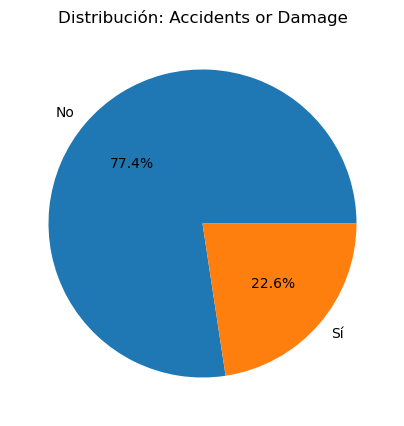

In [108]:
df['accidents_or_damage'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(5,5),
    labels=['No', 'Sí']
)
plt.title("Distribución: Accidents or Damage")
plt.ylabel("")
plt.show()


### <u>Distribución si solo tiene un dueño</u>

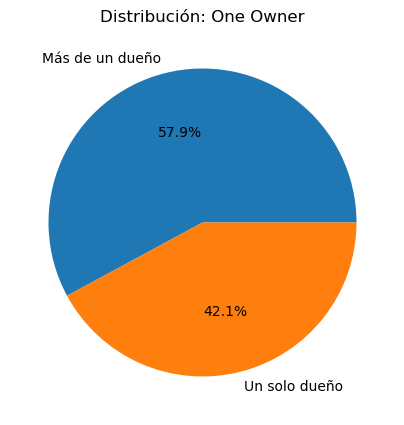

In [109]:
df['one_owner'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(5,5),
    labels=['Más de un dueño', 'Un solo dueño']
)
plt.title("Distribución: One Owner")
plt.ylabel("")
plt.show()


### <u>Distribución del uso personal</u>

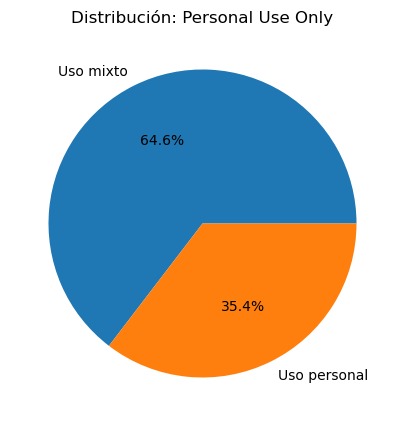

In [110]:
df['personal_use_only'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(5,5),
    labels=['Uso mixto', 'Uso personal'] 
)
plt.title("Distribución: Personal Use Only")
plt.ylabel("")
plt.show()


### <u>Distribución del precio</u>:

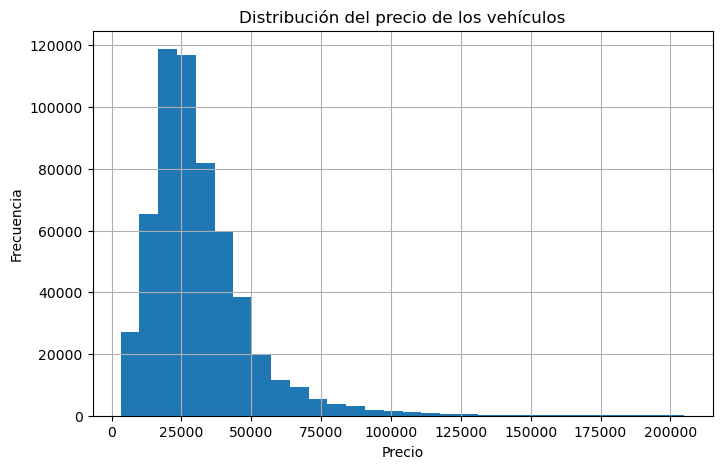

In [111]:
plt.figure(figsize=(8, 5))
df["price"].dropna().hist(bins=30)
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.title("Distribución del precio de los vehículos")
plt.show()

### <u>Precio medio por vendedor (top 10 vendedores con más coches)</u>:

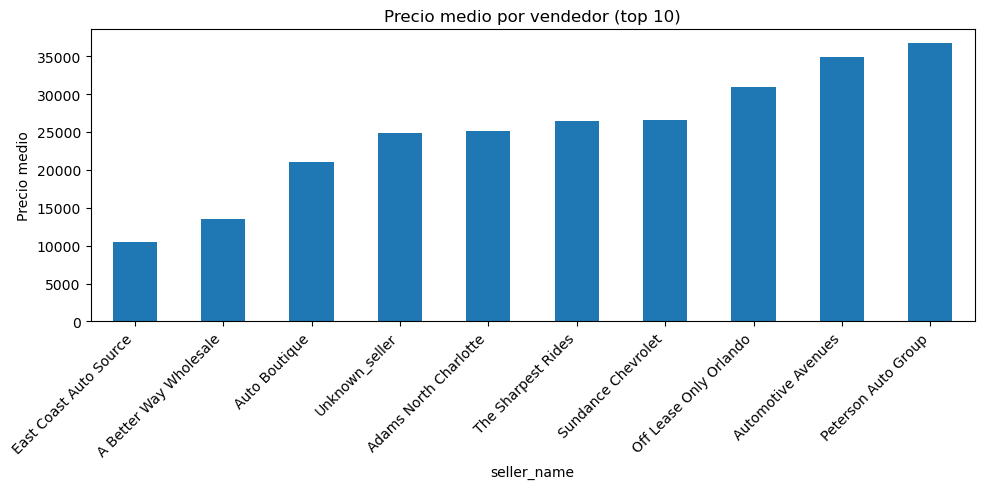

In [112]:
top_sellers = (
    df["seller_name"]
    .value_counts()
    .head(10)
    .index
)

price_by_seller = (
    df[df["seller_name"].isin(top_sellers)]
    .groupby("seller_name")["price"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 5))
price_by_seller.plot(kind="bar")
plt.ylabel("Precio medio")
plt.title("Precio medio por vendedor (top 10)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### <u>Número de reseñas de conductores</u>:

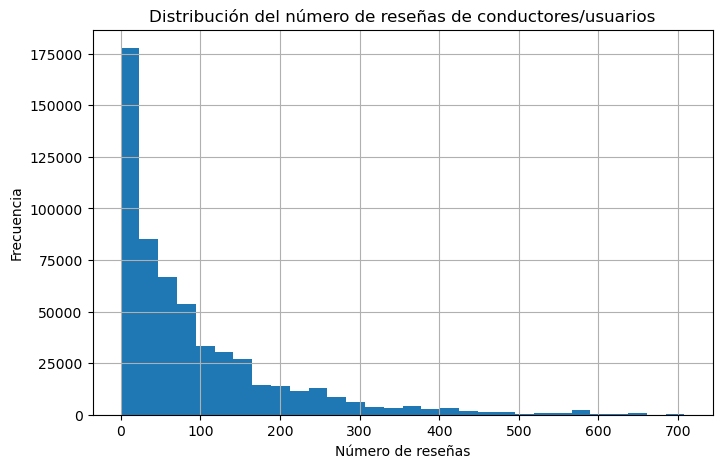

In [113]:
plt.figure(figsize=(8, 5))
df["driver_reviews_num"].dropna().hist(bins=30)
plt.xlabel("Número de reseñas")
plt.ylabel("Frecuencia")
plt.title("Distribución del número de reseñas de conductores/usuarios")
plt.show()